# Notebook to test the effect of faceting on sidelobes

Dimensionless DFT is assumed although this doesn't really change much

In [1]:
import matplotlib
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import norm

def idft_cf(n, N):
    if np.abs(np.exp(2*np.pi*1j*n/N) - 1) == 0:
        return 0
        
    return 1/N * (np.exp(2*np.pi*1j*n) - 1) / (np.exp(2*np.pi*1j*n/N) - 1)

def idft_weights(n, N, w):
    result = 0

    for k in range(N):
        result += w * np.exp(2*np.pi*1j*n*k/N)
    
    return 1/N * result

## Effect of inverse DFT based on number of samples using closed form i.e, no/natural weighting

In [17]:
Nfacet = 50
Nfull = 500
sampleres = 10
xrange_facet = range(Nfacet*sampleres)
xrange_full = range(Nfull*sampleres)
xrange = [x/sampleres for x in xrange_facet[0:Nfacet//2*sampleres]]
xrangefull = [x/sampleres for x in xrange_full[0:Nfull//2*sampleres]]

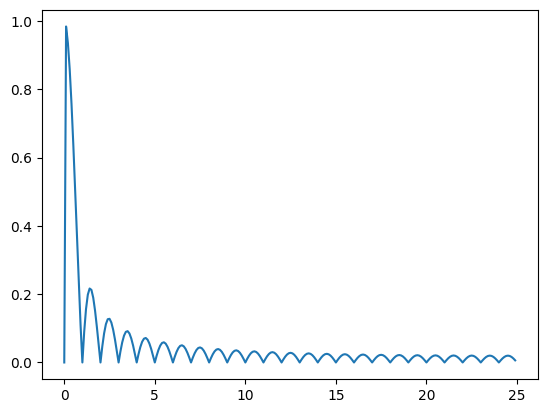

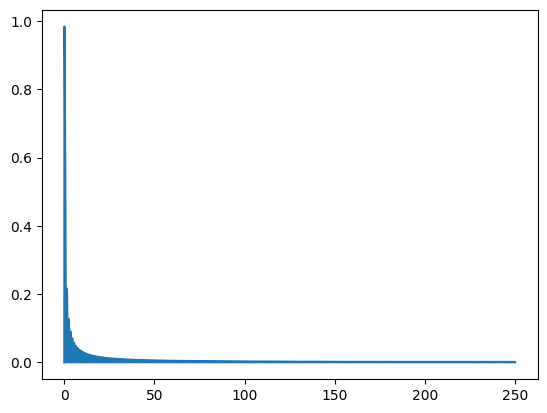

In [18]:
facet = [np.abs(idft_cf(n/sampleres, Nfacet)) for n in xrange_facet]
full = [np.abs(idft_cf(n/sampleres, Nfull)) for n in xrange_full]

plt.plot(xrange, facet[0:Nfacet//2*sampleres], label="facet")
plt.show()
plt.plot(xrangefull, full[0:Nfull//2*sampleres], label="full")
plt.show()


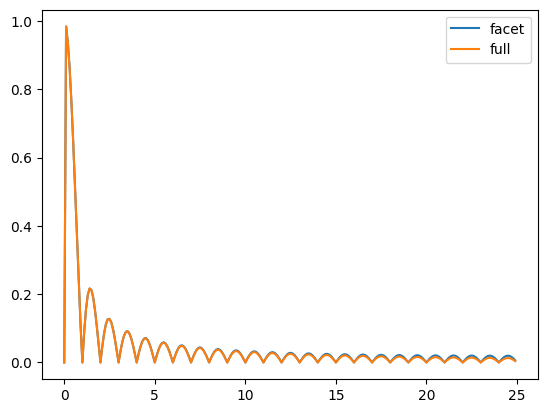

In [19]:
plt.plot(xrange, facet[0:Nfacet//2*sampleres], label="facet")
plt.plot(xrange, full[0:Nfacet//2*sampleres], label="full")
plt.legend()

plt.show()

## Now factoring in weights (gaussian)

### Closed for reweighting

In [5]:
mu = 0
sigmas = [1/2, 1/4]

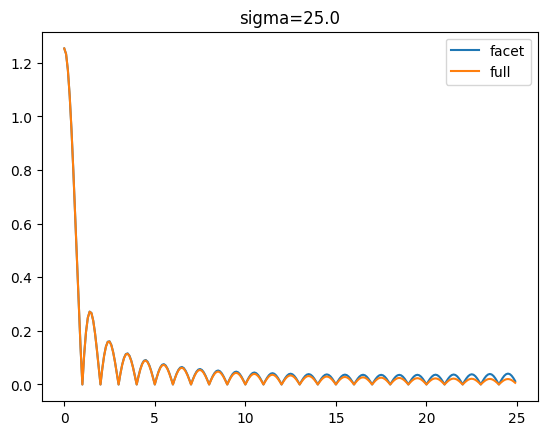

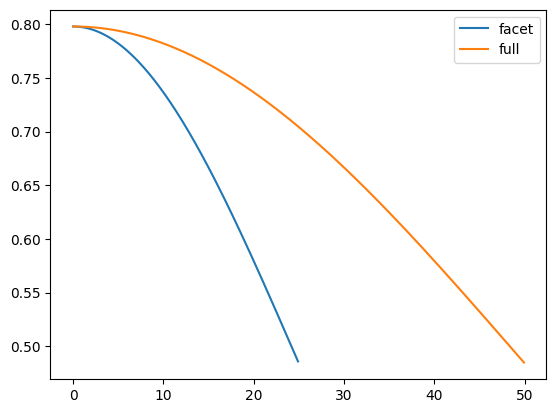

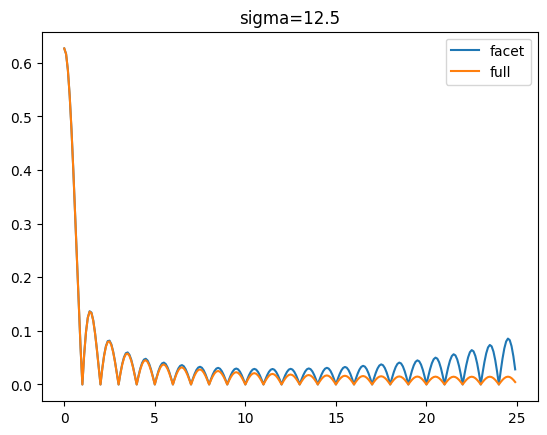

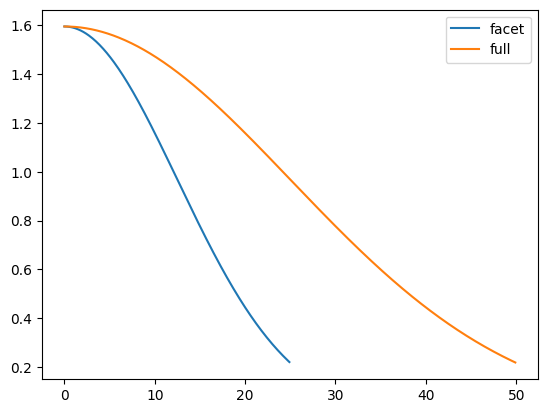

In [6]:
for sigma in sigmas:
    gaussfacet = [norm.pdf(n/(sampleres*Nfacet), loc=mu, scale=sigma) for n in xrange_facet]
    weightsfacet = [1 / x for x in gaussfacet]

    gaussfull = [norm.pdf(n/(sampleres*Nfull), loc=mu, scale=sigma) for n in xrange_full]
    weightsfull = [1 / x for x in gaussfull]

    tfacet = [np.abs(idft_weights(n/sampleres, Nfacet, w)) for (n, w) in zip(xrange_facet, weightsfacet)]
    tfull = [np.abs(idft_weights(n/sampleres, Nfull, w)) for (n, w) in zip(xrange_full, weightsfull)]

    plt.title("sigma=" + str(Nfacet*sigma))
    plt.plot(xrange, tfacet[0:Nfacet//2*sampleres], label="facet")
    plt.plot(xrange, tfull[0:Nfacet//2*sampleres], label="full")
    plt.legend()
    plt.show()

    plt.plot(xrange, gaussfacet[0:Nfacet//2*sampleres], label="facet")
    plt.plot(xrangefull, gaussfull[0:Nfull//2*sampleres], label="full")
    plt.legend()
    plt.show()


### Discretized reweighting

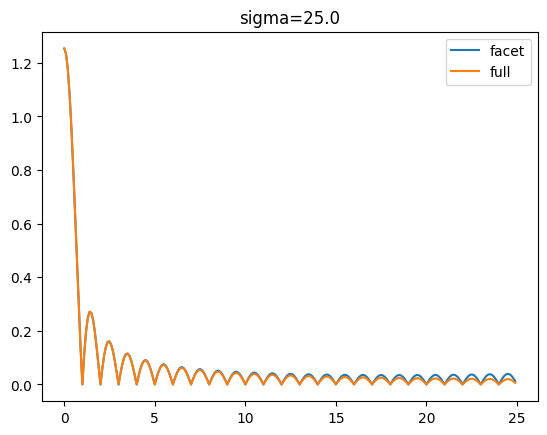

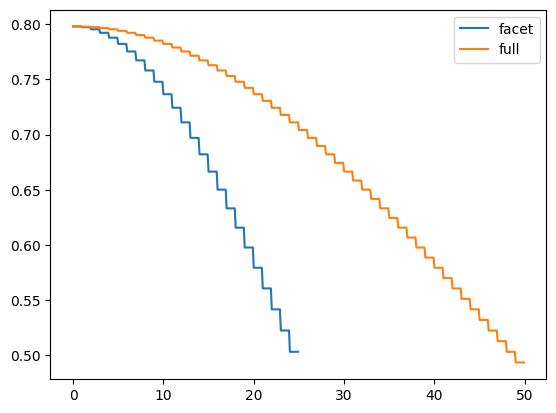

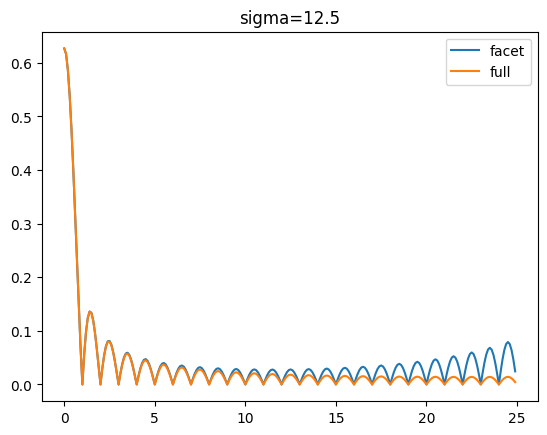

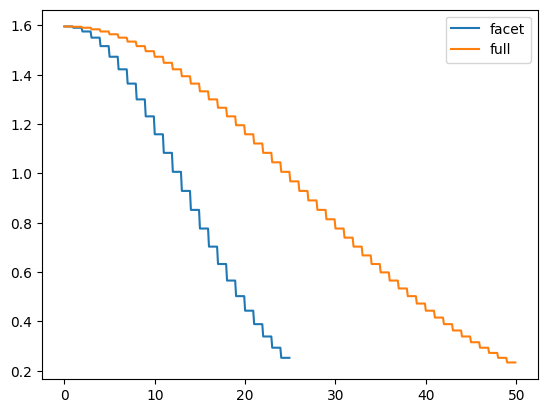

In [7]:
half = sampleres/2
for sigma in sigmas:
    gaussfacet = [norm.pdf((n//sampleres)/Nfacet, loc=mu, scale=sigma) for n in xrange_facet]
    weightsfacet = [1 / x for x in gaussfacet]

    sample_dif = Nfull // Nfacet
    
    gaussfull = [norm.pdf((n//sampleres)/Nfull, loc=mu, scale=sigma) for n in xrange_full]
    weightsfull = [1 / x for x in gaussfull]

    tfacet = [np.abs(idft_weights(n/sampleres, Nfacet, w)) for (n, w) in zip(xrange_facet, weightsfacet)]
    tfull = [np.abs(idft_weights(n/sampleres, Nfull, w)) for (n, w) in zip(xrange_full, weightsfull)]

    plt.title("sigma=" + str(Nfacet*sigma))
    plt.plot(xrange, tfacet[0:Nfacet//2*sampleres], label="facet")
    plt.plot(xrange, tfull[0:Nfacet//2*sampleres], label="full")
    plt.legend()
    plt.show()

    plt.plot(xrange, gaussfacet[0:Nfacet//2*sampleres], label="facet")
    plt.plot(xrangefull, gaussfull[0:Nfull//2*sampleres], label="full")
    plt.legend()
    plt.show()
